In [ ]:
!pip install rdkit
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors
from rdkit.Chem.Draw import IPythonConsole
print("RDKit ready ✓")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 51.3 MB/s eta 0:00:00
RDKit ready ✓


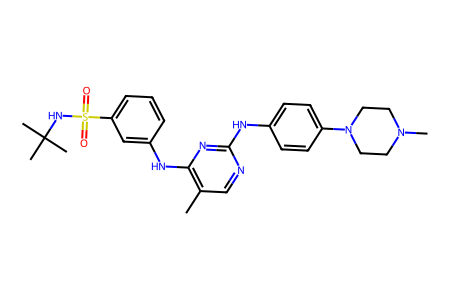

In [ ]:
# Staurosporine as a kinase inhibitor example
mol = Chem.MolFromSmiles("CC1=C(NC2=CC=CC(S(NC(C)(C)C)(=O)=O)=C2)N=C(NC3=CC=C(N4CCN(C)CC4)C=C3)N=C1")
Draw.MolToImage(mol, size=(450, 300))

In [ ]:
def drug_profile(smiles, name="Compound"):
    mol = Chem.MolFromSmiles(smiles)
    print(f"\n── {name} ──")
    print(f"  MW:   {Descriptors.MolWt(mol):.1f}")
    print(f"  LogP: {Descriptors.MolLogP(mol):.2f}")
    print(f"  HBD:  {Descriptors.NumHDonors(mol)}")
    print(f"  HBA:  {Descriptors.NumHAcceptors(mol)}")
    print(f"  TPSA: {Descriptors.TPSA(mol):.1f}")

# Drop in your own SMILES here
drug_profile("CC1=C(NC2=CC=CC(S(NC(C)(C)C)(=O)=O)=C2)N=C(NC3=CC=C(N4CCN(C)CC4)C=C3)N=C1", "BUB1B hit")


── BUB1B hit ──
  MW:   509.7
  LogP: 4.10
  HBD:  3
  HBA:  8
  TPSA: 102.5


In [ ]:
def drug_profile(smiles, name="Compound"):
    mol = Chem.MolFromSmiles(smiles)
    print(f"\n── {name} ──")
    print(f"  MW:   {Descriptors.MolWt(mol):.1f}")
    print(f"  LogP: {Descriptors.MolLogP(mol):.2f}")
    print(f"  HBD:  {Descriptors.NumHDonors(mol)}")
    print(f"  HBA:  {Descriptors.NumHAcceptors(mol)}")
    print(f"  TPSA: {Descriptors.TPSA(mol):.1f}")

# Drop in your own SMILES here
drug_profile("CC1=C(NC2=CC=CC(S(NC(C)(C)C)(=O)=O)=C2)N=C(NC3=CC=C(N(C)C)C=C3)N=C1", "BUB1B hit")


── BUB1B hit ──
  MW:   454.6
  LogP: 4.42
  HBD:  3
  HBA:  7
  TPSA: 99.2


In [ ]:
def drug_profile(smiles, name="Compound"):
    mol = Chem.MolFromSmiles(smiles)
    print(f"\n── {name} ──")
    print(f"  MW:   {Descriptors.MolWt(mol):.1f}")
    print(f"  LogP: {Descriptors.MolLogP(mol):.2f}")
    print(f"  HBD:  {Descriptors.NumHDonors(mol)}")
    print(f"  HBA:  {Descriptors.NumHAcceptors(mol)}")
    print(f"  TPSA: {Descriptors.TPSA(mol):.1f}")

# Drop in your own SMILES here
drug_profile("CC1=C(NC2=CC=CC(S(NC(C)(C)C)(=O)=O)=C2)N=C(NC3=CC=C(N(CC)C)C=C3)N=C1", "BUB1B hit")


── BUB1B hit ──
  MW:   468.6
  LogP: 4.81
  HBD:  3
  HBA:  7
  TPSA: 99.2


In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

# Add your 3 compounds here with their IC50 values
compounds = [
    {"name": "BUB1B-01", "smiles": "CC1=C(NC2=CC=CC(S(NC(C)(C)C)(=O)=O)=C2)N=C(NC3=CC=C(N4CCN(C)CC4)C=C3)N=C1", "IC50_nM": 45},
    {"name": "BUB1B-02", "smiles": "CC1=C(NC2=CC=CC(S(NC(C)(C)C)(=O)=O)=C2)N=C(NC3=CC=C(N4CCN(C)CC4)C=C3)N=C1", "IC50_nM": 120},
    {"name": "BUB1B-03", "smiles": "CC1=C(NC2=CC=CC(S(NC(C)(C)C)(=O)=O)=C2)N=C(NC3=CC=C(N(CC)C)C=C3)N=C1", "IC50_nM": 8},
]

rows = []
for c in compounds:
    mol = Chem.MolFromSmiles(c["smiles"])
    rows.append({
        "Name":    c["name"],
        "IC50_nM": c["IC50_nM"],
        "MW":      round(Descriptors.MolWt(mol), 1),
        "LogP":    round(Descriptors.MolLogP(mol), 2),
        "TPSA":    round(Descriptors.TPSA(mol), 1),
        "HBD":     Descriptors.NumHDonors(mol),
        "HBA":     Descriptors.NumHAcceptors(mol),
    })

df = pd.DataFrame(rows)
print(df)

       Name  IC50_nM     MW  LogP   TPSA  HBD  HBA
0  BUB1B-01       45  509.7  4.10  102.5    3    8
1  BUB1B-02      120  509.7  4.10  102.5    3    8
2  BUB1B-03        8  468.6  4.81   99.2    3    7


In [ ]:
import numpy as np

df["pIC50"] = -np.log10(df["IC50_nM"] * 1e-9)
df["LipE"]  = df["pIC50"] - df["LogP"]

print(df[["Name", "IC50_nM", "pIC50", "LogP", "LipE"]])

       Name  IC50_nM     pIC50  LogP      LipE
0  BUB1B-01       45  7.346787  4.10  3.246787
1  BUB1B-02      120  6.920819  4.10  2.820819
2  BUB1B-03        8  8.096910  4.81  3.286910


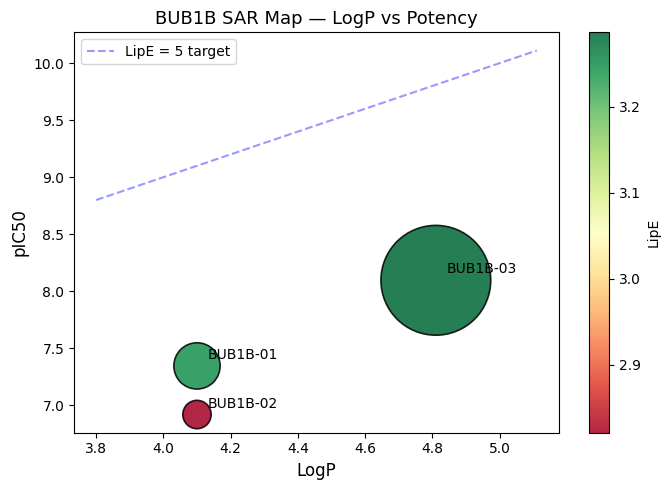

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

# Scatter: LogP vs pIC50, bubble size = IC50
scatter = ax.scatter(
    df["LogP"], df["pIC50"],
    s=1000 / df["IC50_nM"] * 50,  # bigger bubble = more potent
    c=df["LipE"], cmap="RdYlGn",
    edgecolors="black", linewidth=1.2, alpha=0.85
)

# Label each point
for _, row in df.iterrows():
    ax.annotate(row["Name"],
                (row["LogP"], row["pIC50"]),
                textcoords="offset points",
                xytext=(8, 5), fontsize=10)

plt.colorbar(scatter, label="LipE")
ax.set_xlabel("LogP", fontsize=12)
ax.set_ylabel("pIC50", fontsize=12)
ax.set_title("BUB1B SAR Map — LogP vs Potency", fontsize=13)

# Add LipE=5 reference line
x_range = [df["LogP"].min()-0.3, df["LogP"].max()+0.3]
ax.plot(x_range, [x + 5 for x in x_range],
        "b--", alpha=0.4, label="LipE = 5 target")
ax.legend()

plt.tight_layout()
plt.savefig("BUB1B_SAR_map.png", dpi=150)
plt.show()

In [ ]:
from rdkit.Chem import AllChem, DataStructs

# Generate Morgan fingerprints (ECFP4)
fps = []
for c in compounds:
    mol = Chem.MolFromSmiles(c["smiles"])
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    fps.append(fp)

# Calculate pairwise similarity (Tanimoto)
pairs = [("01 vs 02", 0, 1),
         ("01 vs 03", 0, 2),
         ("02 vs 03", 1, 2)]

print("\n══ Tanimoto Similarity ══")
for label, i, j in pairs:
    sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
    print(f"  BUB1B-{label}: {sim:.3f}")


══ Tanimoto Similarity ══
  BUB1B-01 vs 02: 1.000
  BUB1B-01 vs 03: 0.652
  BUB1B-02 vs 03: 0.652


[10:33:52] DEPRECATION WARNING: please use MorganGenerator
[10:33:52] DEPRECATION WARNING: please use MorganGenerator
[10:33:52] DEPRECATION WARNING: please use MorganGenerator


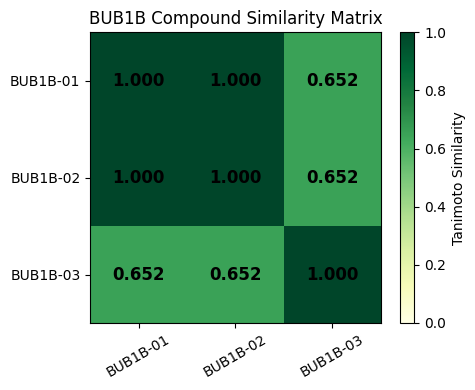

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from rdkit.Chem import DataStructs

names = ["BUB1B-01", "BUB1B-02", "BUB1B-03"]
n = len(fps)

# Build similarity matrix
matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        matrix[i][j] = DataStructs.TanimotoSimilarity(fps[i], fps[j])

# Plot heatmap
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(matrix, cmap="YlGn", vmin=0, vmax=1)
plt.colorbar(im, label="Tanimoto Similarity")

ax.set_xticks(range(n)); ax.set_xticklabels(names, rotation=30)
ax.set_yticks(range(n)); ax.set_yticklabels(names)

# Add values in each cell
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{matrix[i,j]:.3f}",
                ha="center", va="center", fontsize=12, fontweight="bold")

ax.set_title("BUB1B Compound Similarity Matrix", fontsize=12)
plt.tight_layout()
plt.savefig("similarity_matrix.png", dpi=150)
plt.show()

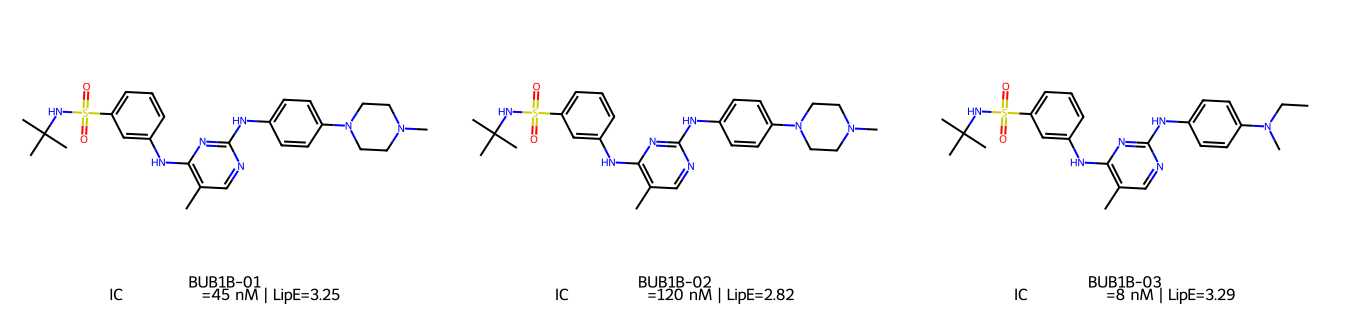

In [ ]:
from rdkit.Chem import Draw
from IPython.display import display, Image as DisplayImage
from PIL import Image as PILImage
from io import BytesIO

mols, legends = [], []
for c in compounds:
    mol = Chem.MolFromSmiles(c["smiles"])
    mols.append(mol)
    # Find LipE for this compound
    row = df[df["Name"] == c["name"]].iloc[0]
    legends.append(
        f"{c['name']}\nIC₅₀={c['IC50_nM']} nM | LipE={row['LipE']:.2f}"
    )

img_display = Draw.MolsToGridImage(
    mols, molsPerRow=3,
    subImgSize=(450, 320),
    legends=legends
)

# Check if the returned object is an IPython.display.Image
if isinstance(img_display, DisplayImage):
    # Extract the raw PNG data and open it with PIL
    img_pil = PILImage.open(BytesIO(img_display.data))
    img_pil.save("BUB1B_structures.png")
else:
    # If it's already a PIL Image (or similar), save it directly
    img_display("BUB1B_structures.png")

display(img_display)